# Imports, paths, metadata, and test data

In [3]:
# ============================================================
# Cell 1: Imports, Configuration, Metadata, and Test Data
# ============================================================

from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")


# ============================================================
# Paths
# ============================================================

PROCESSED_DATA_DIR = Path("../Data/Processed")
MODEL_DIR = Path("../Models")
RESULTS_DIR = Path("../Results")

TEST_PATH = (
    PROCESSED_DATA_DIR
    / "test_air_quality.parquet"
)

PREPROCESSOR_PATH = (
    PROCESSED_DATA_DIR
    / "preprocessing_metadata.pkl"
)

TFT_MODEL_PATH = (
    MODEL_DIR
    / "tft_model.pth"
)

PATCHTST_MODEL_PATH = (
    MODEL_DIR
    / "patchtst_model.pth"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Device
# ============================================================

if torch.cuda.is_available():

    DEVICE = torch.device("cuda")

elif torch.backends.mps.is_available():

    DEVICE = torch.device("mps")

else:

    DEVICE = torch.device("cpu")


# ============================================================
# Validate Required Files
# ============================================================

required_files = [
    TEST_PATH,
    PREPROCESSOR_PATH,
    TFT_MODEL_PATH,
    PATCHTST_MODEL_PATH,
]

for path in required_files:

    if not path.exists():

        raise FileNotFoundError(
            f"Required file not found: {path}"
        )


# ============================================================
# Load Preprocessing Metadata
# ============================================================

with open(
    PREPROCESSOR_PATH,
    "rb",
) as file:

    metadata = pickle.load(file)


ENCODER_LENGTH = metadata[
    "encoder_length"
]

PREDICTION_LENGTH = metadata[
    "prediction_length"
]

TARGET_COLUMNS = metadata[
    "target_columns"
]

NUMERIC_FEATURE_COLUMNS = metadata[
    "numeric_feature_columns"
]

NORMALIZATION_COLUMNS = metadata[
    "normalization_columns"
]

NORMALIZATION_STATS = metadata[
    "normalization_stats"
]


# ============================================================
# Feature Configuration
# ============================================================

FEATURE_COLUMNS = [
    column
    for column in NUMERIC_FEATURE_COLUMNS
    if column != "time_idx"
]

TARGET_INDICES = [
    FEATURE_COLUMNS.index(column)
    for column in TARGET_COLUMNS
]

NUM_FEATURES = len(FEATURE_COLUMNS)

NUM_TARGETS = len(TARGET_COLUMNS)


# ============================================================
# Load Test Data
# ============================================================

test_df = pd.read_parquet(
    TEST_PATH
)

test_df["station_id"] = (
    test_df["station_id"]
    .astype(str)
)

test_df["sequence_segment_id"] = (
    test_df["sequence_segment_id"]
    .astype(str)
)

test_df.sort_values(
    [
        "station_id",
        "sequence_segment_id",
        "timestamp",
    ],
    inplace=True,
)

test_df.reset_index(
    drop=True,
    inplace=True,
)


# ============================================================
# Validate Required Columns
# ============================================================

required_columns = set(
    FEATURE_COLUMNS
    + [
        "station_id",
        "sequence_segment_id",
        "timestamp",
    ]
)

missing_columns = (
    required_columns
    - set(test_df.columns)
)

if missing_columns:

    raise ValueError(
        "Missing required test columns: "
        f"{sorted(missing_columns)}"
    )


# ============================================================
# Convert Features to Numeric
# ============================================================

for column in FEATURE_COLUMNS:

    test_df[column] = pd.to_numeric(
        test_df[column],
        errors="coerce",
    )


# ============================================================
# Replace Infinite Values with NaN
# ============================================================

test_df[FEATURE_COLUMNS] = (
    test_df[FEATURE_COLUMNS]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
)


# ============================================================
# Diagnostics Before NaN Handling
# ============================================================

print("=" * 65)

print(
    "TEST DATA DIAGNOSTICS "
    "BEFORE MISSING VALUE HANDLING"
)

print("=" * 65)


problem_columns = []

for column in FEATURE_COLUMNS:

    nan_count = int(
        test_df[column]
        .isna()
        .sum()
    )

    if nan_count > 0:

        problem_columns.append(
            (
                column,
                nan_count,
            )
        )


if problem_columns:

    for (
        column,
        nan_count,
    ) in problem_columns:

        print(
            f"{column:<35} | "
            f"NaN: {nan_count:>10,}"
        )

else:

    print(
        "No missing feature values found."
    )


# ============================================================
# Handle hours_since_previous
# ============================================================

if (
    "hours_since_previous"
    in test_df.columns
):

    gap_missing_count = int(
        test_df[
            "hours_since_previous"
        ]
        .isna()
        .sum()
    )

    test_df[
        "hours_since_previous"
    ] = (
        test_df[
            "hours_since_previous"
        ]
        .fillna(0.0)
        .astype(np.float32)
    )

    if gap_missing_count > 0:

        print(
            "\nhours_since_previous "
            f"filled: {gap_missing_count:,}"
        )


# ============================================================
# Fill Remaining NaNs Using Training Mean
# ============================================================

print("\n" + "=" * 65)

print(
    "MISSING VALUE IMPUTATION"
)

print("=" * 65)


imputed_columns = []


for column in FEATURE_COLUMNS:

    missing_count = int(
        test_df[column]
        .isna()
        .sum()
    )

    if missing_count == 0:

        continue


    if column not in NORMALIZATION_STATS:

        raise ValueError(
            "No training normalization "
            f"statistics available for: {column}"
        )


    stats = NORMALIZATION_STATS[
        column
    ]

    training_mean = float(
        stats["mean"]
    )


    if not np.isfinite(
        training_mean
    ):

        raise ValueError(
            "Invalid training mean for "
            f"{column}: {training_mean}"
        )


    test_df[column] = (
        test_df[column]
        .fillna(training_mean)
    )


    imputed_columns.append(
        (
            column,
            missing_count,
            training_mean,
        )
    )


if imputed_columns:

    for (
        column,
        missing_count,
        training_mean,
    ) in imputed_columns:

        print(
            f"{column:<35} | "
            f"Filled: {missing_count:>10,} | "
            f"Training mean: "
            f"{training_mean:.4f}"
        )

else:

    print(
        "No additional missing values "
        "required imputation."
    )


# ============================================================
# Validate Normalization Statistics
# ============================================================

for column in NORMALIZATION_COLUMNS:

    if (
        column
        not in NORMALIZATION_STATS
    ):

        raise KeyError(
            "Missing normalization "
            f"statistics for: {column}"
        )


    stats = NORMALIZATION_STATS[
        column
    ]

    mean = float(
        stats["mean"]
    )

    std = float(
        stats["std"]
    )


    if not np.isfinite(mean):

        raise ValueError(
            f"Invalid mean for {column}: "
            f"{mean}"
        )


    if (
        not np.isfinite(std)
        or std <= 0
    ):

        raise ValueError(
            f"Invalid standard deviation "
            f"for {column}: {std}"
        )


# ============================================================
# Normalize Test Data
# ============================================================

for column in NORMALIZATION_COLUMNS:

    stats = NORMALIZATION_STATS[
        column
    ]

    mean = float(
        stats["mean"]
    )

    std = float(
        stats["std"]
    )


    test_df[column] = (
        (
            test_df[column]
            .astype(np.float32)
            - mean
        )
        / std
    ).astype(np.float32)


# ============================================================
# Final Data Validation
# ============================================================

test_values = test_df[
    FEATURE_COLUMNS
].to_numpy(
    dtype=np.float32
)


nan_mask = np.isnan(
    test_values
)

inf_mask = np.isinf(
    test_values
)


print("\n" + "=" * 65)

print(
    "TEST DATA DIAGNOSTICS "
    "AFTER NORMALIZATION"
)

print("=" * 65)


print(
    f"NaN values : "
    f"{int(nan_mask.sum()):,}"
)

print(
    f"Inf values : "
    f"{int(inf_mask.sum()):,}"
)


if (
    nan_mask.any()
    or inf_mask.any()
):

    print(
        "\nProblematic columns:"
    )


    for (
        column_index,
        column,
    ) in enumerate(
        FEATURE_COLUMNS
    ):

        nan_count = int(
            nan_mask[
                :,
                column_index,
            ].sum()
        )

        inf_count = int(
            inf_mask[
                :,
                column_index,
            ].sum()
        )


        if (
            nan_count > 0
            or inf_count > 0
        ):

            print(
                f"{column:<35} | "
                f"NaN: {nan_count:>10,} | "
                f"Inf: {inf_count:>10,}"
            )


    raise ValueError(
        "Test data still contains "
        "NaN or Inf."
    )


# ============================================================
# Configuration Summary
# ============================================================

print("\n" + "=" * 65)

print(
    "MODEL EVALUATION CONFIGURATION"
)

print("=" * 65)


print(
    f"Device             : "
    f"{DEVICE}"
)

print(
    f"Test rows          : "
    f"{len(test_df):,}"
)

print(
    f"Features           : "
    f"{NUM_FEATURES}"
)

print(
    f"Targets            : "
    f"{NUM_TARGETS}"
)

print(
    f"Encoder length     : "
    f"{ENCODER_LENGTH}"
)

print(
    f"Prediction length  : "
    f"{PREDICTION_LENGTH}"
)


print(
    "\nTest data prepared "
    "successfully."
)

TEST DATA DIAGNOSTICS BEFORE MISSING VALUE HANDLING
ambient_temperature                 | NaN:         10

MISSING VALUE IMPUTATION
ambient_temperature                 | Filled:         10 | Training mean: 26.6172

TEST DATA DIAGNOSTICS AFTER NORMALIZATION
NaN values : 0
Inf values : 0

MODEL EVALUATION CONFIGURATION
Device             : mps
Test rows          : 674,665
Features           : 32
Targets            : 9
Encoder length     : 168
Prediction length  : 15

Test data prepared successfully.


# 2. Dataset and exact trained model architures

In [4]:
# ============================================================
# Lazy Test Window Dataset
# ============================================================

class AirQualityWindowDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_columns,
        target_indices,
        encoder_length,
        prediction_length,
    ):

        self.encoder_length = encoder_length
        self.prediction_length = prediction_length

        self.target_indices = np.asarray(
            target_indices,
            dtype=np.int64,
        )

        self.values = dataframe[
            feature_columns
        ].to_numpy(dtype=np.float32)

        self.window_starts = []

        grouped_indices = dataframe.groupby(
            [
                "station_id",
                "sequence_segment_id",
            ],
            sort=False,
            observed=True,
        ).indices

        required_length = (
            encoder_length
            + prediction_length
        )

        for indices in grouped_indices.values():

            indices = np.asarray(indices)

            number_of_windows = (
                len(indices)
                - required_length
                + 1
            )

            if number_of_windows <= 0:
                continue

            segment_start = int(indices[0])

            self.window_starts.extend(
                range(
                    segment_start,
                    segment_start
                    + number_of_windows,
                )
            )

        self.window_starts = np.asarray(
            self.window_starts,
            dtype=np.int64,
        )

    def __len__(self):

        return len(self.window_starts)

    def __getitem__(self, index):

        start = self.window_starts[index]

        encoder_end = (
            start + self.encoder_length
        )

        prediction_end = (
            encoder_end
            + self.prediction_length
        )

        x = self.values[
            start:encoder_end
        ]

        y = self.values[
            encoder_end:prediction_end,
            self.target_indices,
        ]

        return (
            torch.from_numpy(x),
            torch.from_numpy(y),
        )


# ============================================================
# Exact TFT Architecture from Notebook 07
# ============================================================

class TFTModel(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        prediction_length,
        num_targets,
        dropout,
    ):

        super().__init__()

        self.prediction_length = prediction_length
        self.num_targets = num_targets

        self.variable_gate = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Sigmoid(),
        )

        self.input_projection = nn.Linear(
            input_size,
            hidden_size,
        )

        self.temporal_encoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=4,
            dropout=0.0,
            batch_first=True,
        )

        self.normalization = nn.LayerNorm(
            hidden_size
        )

        self.dropout = nn.Dropout(dropout)

        self.output_layer = nn.Linear(
            hidden_size,
            prediction_length * num_targets,
        )

    def forward(self, x):

        gate = self.variable_gate(x)

        x = x * gate

        x = self.input_projection(x)

        encoded, _ = self.temporal_encoder(x)

        attended, _ = self.attention(
            encoded,
            encoded,
            encoded,
            need_weights=False,
        )

        encoded = self.normalization(
            encoded + attended
        )

        context = encoded[:, -1]

        context = self.dropout(context)

        output = self.output_layer(context)

        return output.view(
            -1,
            self.prediction_length,
            self.num_targets,
        )


# ============================================================
# Exact PatchTST Architecture from Notebook 07
# ============================================================

class PatchTSTModel(nn.Module):

    def __init__(
        self,
        input_size,
        encoder_length,
        prediction_length,
        num_targets,
        hidden_size,
        patch_length,
        patch_stride,
        dropout,
    ):

        super().__init__()

        self.patch_length = patch_length
        self.patch_stride = patch_stride

        self.prediction_length = prediction_length
        self.num_targets = num_targets

        self.num_patches = (
            (
                encoder_length
                - patch_length
            )
            // patch_stride
        ) + 1

        self.patch_projection = nn.Linear(
            patch_length * input_size,
            hidden_size,
        )

        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                self.num_patches,
                hidden_size,
            )
        )

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=hidden_size,
                nhead=4,
                dim_feedforward=hidden_size * 4,
                dropout=0.0,
                batch_first=True,
                norm_first=True,
            )
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=3,
        )

        self.normalization = nn.LayerNorm(
            hidden_size
        )

        self.dropout = nn.Dropout(dropout)

        self.output_layer = nn.Linear(
            hidden_size,
            prediction_length * num_targets,
        )

    def forward(self, x):

        patches = x.unfold(
            dimension=1,
            size=self.patch_length,
            step=self.patch_stride,
        )

        patches = patches.permute(
            0,
            1,
            3,
            2,
        )

        patches = patches.reshape(
            patches.size(0),
            patches.size(1),
            -1,
        )

        patches = self.patch_projection(patches)

        patches = (
            patches
            + self.position_embedding
        )

        encoded = self.transformer(patches)

        context = self.normalization(
            encoded.mean(dim=1)
        )

        context = self.dropout(context)

        output = self.output_layer(context)

        return output.view(
            -1,
            self.prediction_length,
            self.num_targets,
        )


# ============================================================
# Dataset and Loader
# ============================================================

test_dataset = AirQualityWindowDataset(
    dataframe=test_df,
    feature_columns=FEATURE_COLUMNS,
    target_indices=TARGET_INDICES,
    encoder_length=ENCODER_LENGTH,
    prediction_length=PREDICTION_LENGTH,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("=" * 65)
print("TEST DATASET CREATED")
print("=" * 65)

print(
    f"Test windows : "
    f"{len(test_dataset):,}"
)

sample_x, sample_y = next(
    iter(test_loader)
)

print(f"Sample X : {sample_x.shape}")
print(f"Sample Y : {sample_y.shape}")

TEST DATASET CREATED
Test windows : 479,204
Sample X : torch.Size([128, 168, 32])
Sample Y : torch.Size([128, 15, 9])


# 3. Load models, generate prediction and inverse normalization.

In [5]:
# ============================================================
# Load Checkpoints
# ============================================================

tft_checkpoint = torch.load(
    TFT_MODEL_PATH,
    map_location=DEVICE,
)

patchtst_checkpoint = torch.load(
    PATCHTST_MODEL_PATH,
    map_location=DEVICE,
)

tft_model = TFTModel(
    input_size=NUM_FEATURES,
    hidden_size=128,
    prediction_length=PREDICTION_LENGTH,
    num_targets=NUM_TARGETS,
    dropout=0.1,
).to(DEVICE)

patchtst_model = PatchTSTModel(
    input_size=NUM_FEATURES,
    encoder_length=ENCODER_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    num_targets=NUM_TARGETS,
    hidden_size=128,
    patch_length=24,
    patch_stride=12,
    dropout=0.1,
).to(DEVICE)

tft_model.load_state_dict(
    tft_checkpoint["model_state_dict"]
)

patchtst_model.load_state_dict(
    patchtst_checkpoint["model_state_dict"]
)

tft_model.eval()
patchtst_model.eval()

# ============================================================
# Generate Predictions
# ============================================================

@torch.no_grad()
def generate_predictions(
    model,
    data_loader,
):

    predictions = []
    targets = []

    for batch_x, batch_y in data_loader:

        batch_x = batch_x.to(DEVICE)

        batch_predictions = model(batch_x)

        predictions.append(
            batch_predictions.cpu().numpy()
        )

        targets.append(
            batch_y.numpy()
        )

    return (
        np.concatenate(targets, axis=0),
        np.concatenate(predictions, axis=0),
    )


y_true, tft_pred = generate_predictions(
    tft_model,
    test_loader,
)

patch_true, patchtst_pred = (
    generate_predictions(
        patchtst_model,
        test_loader,
    )
)

if not np.allclose(
    y_true,
    patch_true,
):

    raise ValueError(
        "Model test targets do not match."
    )

# ============================================================
# Inverse Normalize Targets
# ============================================================

def inverse_normalize_targets(values):

    values = values.copy()

    for target_index, target in enumerate(
        TARGET_COLUMNS
    ):

        stats = NORMALIZATION_STATS[target]

        values[:, :, target_index] = (
            values[:, :, target_index]
            * stats["std"]
            + stats["mean"]
        )

    return values


y_true = inverse_normalize_targets(y_true)

tft_pred = inverse_normalize_targets(
    tft_pred
)

patchtst_pred = inverse_normalize_targets(
    patchtst_pred
)

if not (
    np.isfinite(y_true).all()
    and np.isfinite(tft_pred).all()
    and np.isfinite(patchtst_pred).all()
):

    raise ValueError(
        "Predictions contain NaN or Inf."
    )

print("=" * 65)
print("TEST PREDICTIONS GENERATED")
print("=" * 65)

print(f"True shape     : {y_true.shape}")
print(f"TFT shape      : {tft_pred.shape}")
print(
    f"PatchTST shape : "
    f"{patchtst_pred.shape}"
)

print(
    "\nPredictions inverse-normalized "
    "successfully."
)

TEST PREDICTIONS GENERATED
True shape     : (479204, 15, 9)
TFT shape      : (479204, 15, 9)
PatchTST shape : (479204, 15, 9)

Predictions inverse-normalized successfully.


# Complete evaluation: overall, pollutant 

In [6]:
# ============================================================
# Metrics
# ============================================================

def smape(y_true, y_pred):

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
    )

    return 100 * np.mean(
        np.divide(
            2 * np.abs(y_pred - y_true),
            denominator,
            out=np.zeros_like(
                denominator,
                dtype=np.float64,
            ),
            where=denominator != 0,
        )
    )


def calculate_metrics(
    y_true,
    y_pred,
):

    true_flat = y_true.reshape(-1)
    pred_flat = y_pred.reshape(-1)

    return {
        "MAE": mean_absolute_error(
            true_flat,
            pred_flat,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                true_flat,
                pred_flat,
            )
        ),
        "R2": r2_score(
            true_flat,
            pred_flat,
        ),
        "sMAPE": smape(
            true_flat,
            pred_flat,
        ),
    }


models = {
    "TFT": tft_pred,
    "PatchTST": patchtst_pred,
}

# ============================================================
# Overall Metrics
# ============================================================

overall_results = pd.DataFrame({
    model_name: calculate_metrics(
        y_true,
        prediction,
    )
    for model_name, prediction
    in models.items()
}).T

overall_results.index.name = "Model"

# ============================================================
# Pollutant Metrics
# ============================================================

pollutant_records = []

for model_name, prediction in models.items():

    for target_index, target in enumerate(
        TARGET_COLUMNS
    ):

        metrics = calculate_metrics(
            y_true[:, :, target_index],
            prediction[:, :, target_index],
        )

        pollutant_records.append({
            "Model": model_name,
            "Pollutant": target,
            **metrics,
        })

pollutant_results = pd.DataFrame(
    pollutant_records
)

# ============================================================
# Forecast Horizon Metrics
# ============================================================

horizon_records = []

for model_name, prediction in models.items():

    for horizon in range(
        PREDICTION_LENGTH
    ):

        metrics = calculate_metrics(
            y_true[:, horizon, :],
            prediction[:, horizon, :],
        )

        horizon_records.append({
            "Model": model_name,
            "Forecast_Hour": horizon + 1,
            **metrics,
        })

horizon_results = pd.DataFrame(
    horizon_records
)

# ============================================================
# Save Results
# ============================================================

overall_results.to_csv(
    RESULTS_DIR / "overall_model_metrics.csv"
)

pollutant_results.to_csv(
    RESULTS_DIR / "pollutant_metrics.csv",
    index=False,
)

horizon_results.to_csv(
    RESULTS_DIR / "horizon_metrics.csv",
    index=False,
)

np.savez_compressed(
    RESULTS_DIR / "test_predictions.npz",
    y_true=y_true,
    tft_pred=tft_pred,
    patchtst_pred=patchtst_pred,
)

# ============================================================
# Display
# ============================================================

print("=" * 65)
print("OVERALL MODEL PERFORMANCE")
print("=" * 65)

display(overall_results.round(4))

print("\n" + "=" * 65)
print("POLLUTANT-WISE PERFORMANCE")
print("=" * 65)

display(
    pollutant_results.round(4)
)

print("\n" + "=" * 65)
print("15-HOUR FORECAST PERFORMANCE")
print("=" * 65)

display(
    horizon_results.round(4)
)

OVERALL MODEL PERFORMANCE


,MAE,RMSE,R2,sMAPE
Model,,,,
TFT,8.1674,23.2108,0.7890,31.8826
PatchTST,8.1980,22.6484,0.7991,33.2241



POLLUTANT-WISE PERFORMANCE


,Model,Pollutant,MAE,RMSE,R2,sMAPE
0,TFT,pm2_5,13.6605,30.7622,0.6675,29.7827
1,TFT,pm10,28.6810,53.5086,0.6912,27.7767
2,TFT,no,5.2558,17.0058,0.4601,45.3521
3,TFT,no2,5.4532,11.7512,0.7621,26.4695
4,TFT,nox,6.6520,17.2438,0.6135,30.1944
5,TFT,nh3,3.4696,8.5951,0.8048,17.0052
6,TFT,co,0.2169,0.4170,0.6215,53.1936
7,TFT,so2,3.6164,8.5711,0.6343,25.8648
8,TFT,o3,6.5009,12.9235,0.7658,31.3040
9,PatchTST,pm2_5,13.6864,30.0363,0.6830,30.7289



15-HOUR FORECAST PERFORMANCE


,Model,Forecast_Hour,MAE,RMSE,R2,sMAPE
0,TFT,1,5.2220,15.4130,0.9069,25.7256
1,TFT,2,6.4215,18.6723,0.8634,28.0276
2,TFT,3,7.2128,20.7102,0.8319,29.7825
3,TFT,4,7.7562,21.9713,0.8108,31.1818
4,TFT,5,8.1289,22.8852,0.7947,31.9301
5,TFT,6,8.3536,23.4103,0.7852,32.3470
6,TFT,7,8.5328,23.8447,0.7772,32.7397
7,TFT,8,8.6664,24.1864,0.7708,32.9947
8,TFT,9,8.7593,24.4492,0.7659,33.1969
9,TFT,10,8.7731,24.6822,0.7614,33.1389


# comparision plot and final summary

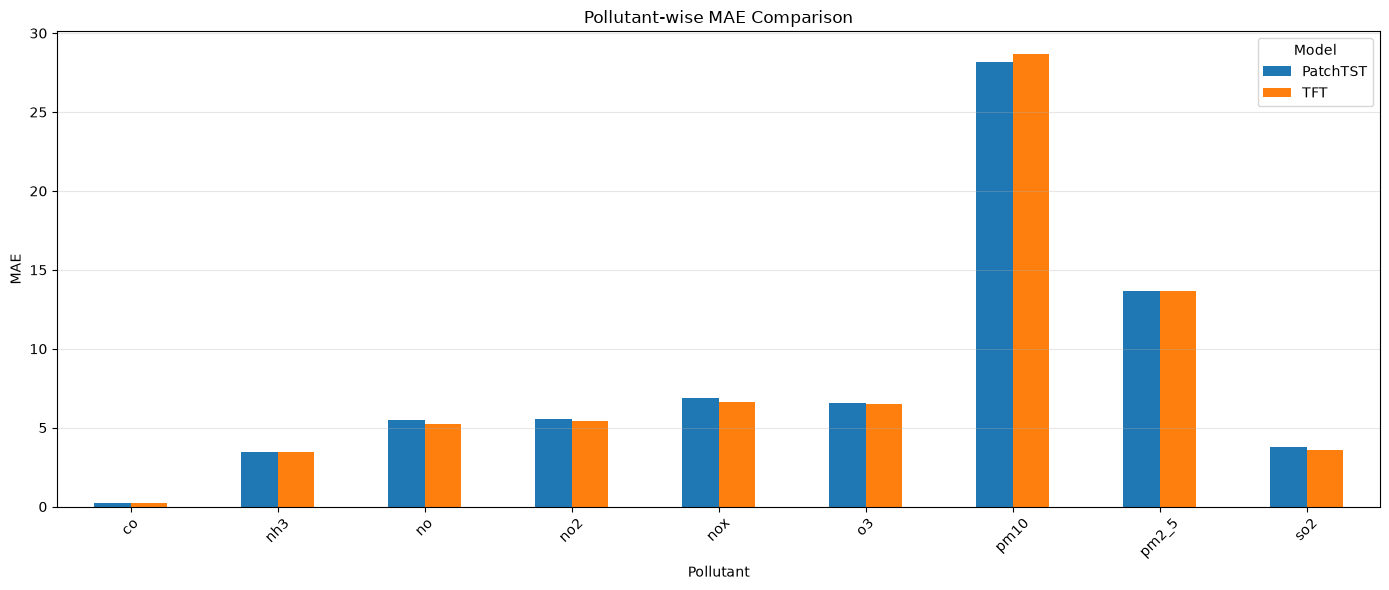

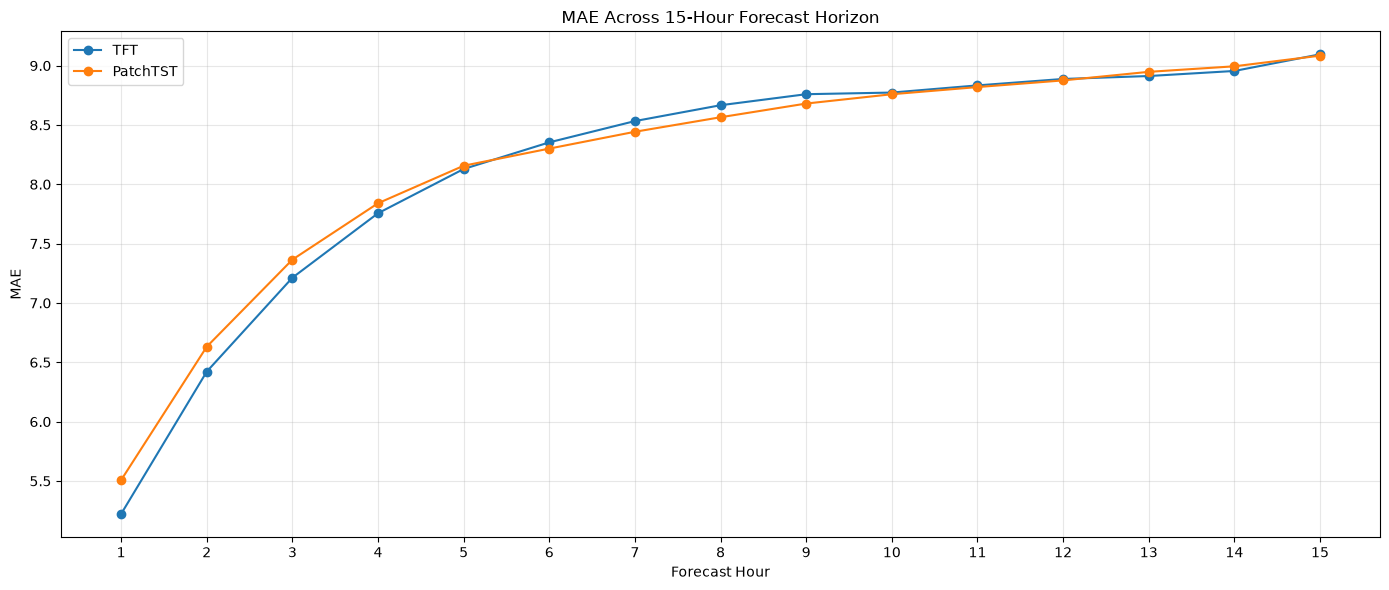

FINAL MODEL EVALUATION SUMMARY

Best overall model: TFT

Best model by pollutant:


,Pollutant,Model,MAE
0,co,PatchTST,0.2162
1,nh3,PatchTST,3.4610
2,no,TFT,5.2558
3,no2,TFT,5.4532
4,nox,TFT,6.6520
5,o3,TFT,6.5009
6,pm10,PatchTST,28.1609
7,pm2_5,TFT,13.6605
8,so2,TFT,3.6164



Best model by forecast hour:


,Forecast_Hour,Model,MAE
0,1,TFT,5.2220
1,2,TFT,6.4215
2,3,TFT,7.2128
3,4,TFT,7.7562
4,5,TFT,8.1289
5,6,PatchTST,8.3010
6,7,PatchTST,8.4427
7,8,PatchTST,8.5651
8,9,PatchTST,8.6805
9,10,PatchTST,8.7589



Saved Evaluation Files
 - horizon_metrics.csv
 - overall_model_metrics.csv
 - pollutant_metrics.csv
 - test_predictions.npz

Model evaluation completed successfully.

Ready for ensemble prediction.


In [7]:
# ============================================================
# Pollutant MAE Plot
# ============================================================

pollutant_mae = pollutant_results.pivot(
    index="Pollutant",
    columns="Model",
    values="MAE",
)

pollutant_mae.plot(
    kind="bar",
    figsize=(14, 6),
)

plt.title(
    "Pollutant-wise MAE Comparison"
)

plt.xlabel("Pollutant")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Forecast Horizon Plot
# ============================================================

plt.figure(figsize=(14, 6))

for model_name in models:

    model_data = horizon_results[
        horizon_results["Model"]
        == model_name
    ]

    plt.plot(
        model_data["Forecast_Hour"],
        model_data["MAE"],
        marker="o",
        label=model_name,
    )

plt.title(
    "MAE Across 15-Hour Forecast Horizon"
)

plt.xlabel("Forecast Hour")
plt.ylabel("MAE")

plt.xticks(
    range(
        1,
        PREDICTION_LENGTH + 1,
    )
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Best Models
# ============================================================

best_overall_model = (
    overall_results["MAE"].idxmin()
)

pollutant_winners = (
    pollutant_results
    .loc[
        pollutant_results
        .groupby("Pollutant")["MAE"]
        .idxmin(),
        [
            "Pollutant",
            "Model",
            "MAE",
        ],
    ]
    .reset_index(drop=True)
)

horizon_winners = (
    horizon_results
    .loc[
        horizon_results
        .groupby("Forecast_Hour")["MAE"]
        .idxmin(),
        [
            "Forecast_Hour",
            "Model",
            "MAE",
        ],
    ]
    .reset_index(drop=True)
)

print("=" * 65)
print("FINAL MODEL EVALUATION SUMMARY")
print("=" * 65)

print(
    f"\nBest overall model: "
    f"{best_overall_model}"
)

print("\nBest model by pollutant:")

display(
    pollutant_winners.round(4)
)

print("\nBest model by forecast hour:")

display(
    horizon_winners.round(4)
)

print("\nSaved Evaluation Files")

for path in sorted(
    RESULTS_DIR.iterdir()
):

    print(f" - {path.name}")

print(
    "\nModel evaluation completed "
    "successfully."
)

print(
    "\nReady for ensemble prediction."
)